# Regresión Logística

En este notebook, se presenta un ejercicio practico de  regresión logística para resolver problemas de clasificación. A lo largo de los ejercicios, se implementan y evaluan modelos de regresión logística utilizando conjuntos de datos reales: el conjunto de datos **Breast Cancer Wisconsin** para clasificación binaria y el conjunto de datos **Wine** para clasificación multiclase.

Primero, se carga el conjunto de datos **Breast Cancer Wisconsin** desde Scikit-Learn. Este dataset es un clásico en machine learning y contiene características computadas a partir de imágenes digitales de células mamarias aspiradas con aguja fina. La tarea es predecir si un tumor es benigno o maligno basado en estas características.




In [1]:
# Importación de librerías básicas
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Manejo de desequilibrio de clases
from imblearn.over_sampling import SMOTE

# Selección de características
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Modelado
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score


In [3]:
from sklearn.datasets import load_breast_cancer

# Cargar los datos de cáncer de mama
data = load_breast_cancer()
X = data.data
y = data.target

# Mostrar la descripción del dataset
print(data.DESCR)


.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

El conjunto de datos incluye 30 características que describen diversas propiedades de las células. Las etiquetas son binarias, 0 para maligno y 1 para benigno. A continuación, se dividen los datos en conjuntos de entrenamiento y prueba, lo que permitirá entrenar el modelo en un subconjunto de los datos y luego evaluarlo en datos que no ha visto antes.

In [4]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

In [7]:
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


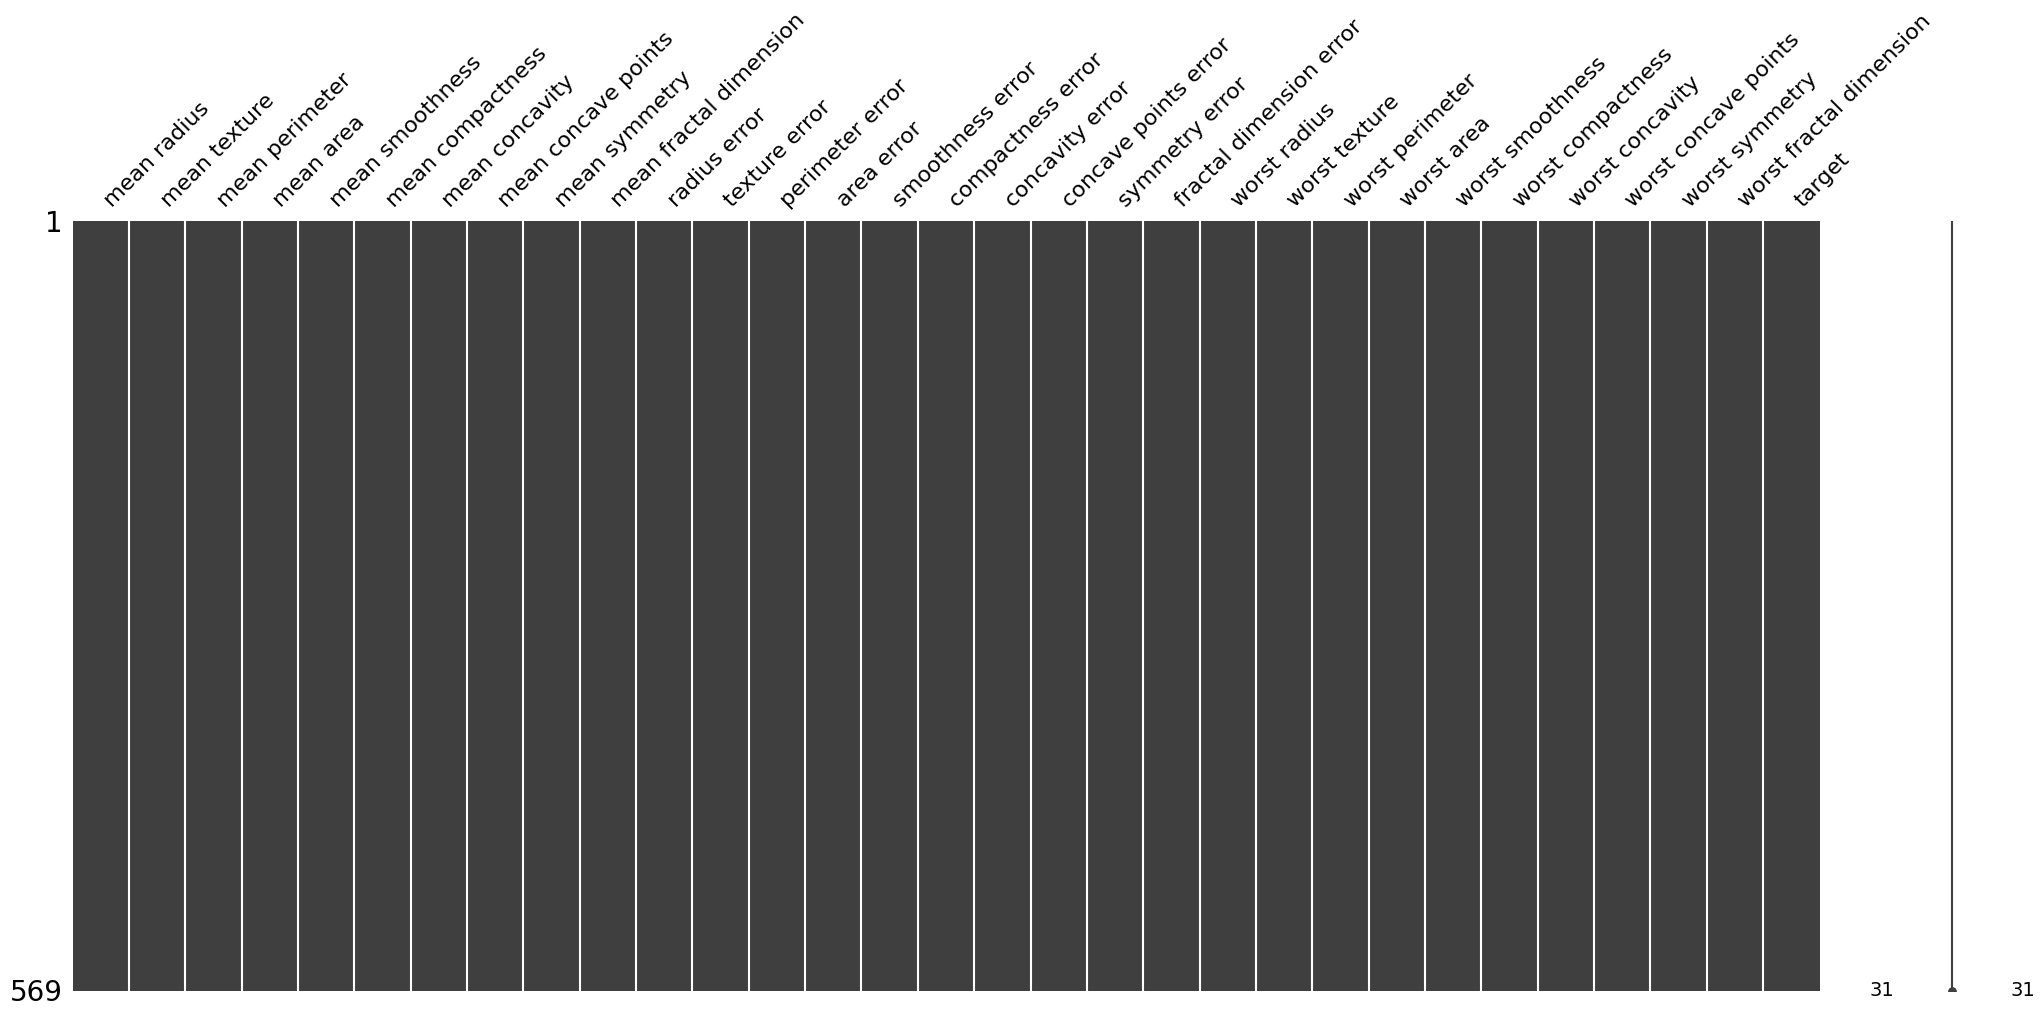

In [5]:
import missingno as msno

# Visualizar los datos perdidos con missingno
msno.matrix(df)
plt.show()



**Verificación de Duplicados**


Verificaremos si existen filas duplicadas en el conjunto de datos.

In [6]:
# Verificar si hay filas duplicadas
duplicate_rows = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicate_rows}")


Número de filas duplicadas: 0
